# Coal gasification + HB ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for Coal gasification + HB at 1,000,000 tNH3/year. The notebook shows NPV, LPM, and LCOA distributions, NPV sign counts, and mean annual cost components. Coal feedstock and process fuel are costed once through the total 9.36 MWh/tNH3.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "coal_gasification_hb"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tnh3,present_value_total_cost_eur,lcoa_eur_per_tnh3,levelized_profit_margin_eur_per_tnh3
0,0,coal_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"3,710.862",125.353,18.749,coal,...,"116,930,605.168",0.000,"256,000,000.000","595,320,825.394","294,679,174.606","-565,227,801.802","10,674,776.189","10,065,778,609.646",942.950,-52.950
1,1,coal_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"2,911.682",118.185,15.385,coal,...,"125,540,267.652",0.000,"256,000,000.000","607,795,283.318","282,204,716.682","100,789,853.386","10,674,776.189","9,399,760,954.458",880.558,9.442
2,2,coal_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"2,749.548",107.988,15.833,coal,...,"103,578,751.807",0.000,"256,000,000.000","603,536,247.810","286,463,752.190","308,388,937.091","10,674,776.189","9,192,161,870.753",861.111,28.889
3,3,coal_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"3,518.263",107.280,16.888,coal,...,"125,764,168.953",0.000,"256,000,000.000","635,699,175.175","254,300,824.825","-803,658,217.599","10,674,776.189","10,304,209,025.443",965.286,-75.286
4,4,coal_gasification_hb,absolute,not_applicable,"1,000,000.000",25,"3,355.594",118.844,16.090,coal,...,"135,354,021.622",0.000,"256,000,000.000","630,132,963.448","259,867,036.552","-581,571,134.730","10,674,776.189","10,082,121,942.574",944.481,-54.481


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_profit_margin_eur_per_tnh3 = results["levelized_profit_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,-306.903,-28.750,918.750
std,490.678,45.966,45.966
min,"-2,434.592",-228.070,757.478
5%,"-1,133.802",-106.213,844.903
50%,-296.767,-27.801,917.801
95%,481.404,45.097,996.213
max,"1,414.638",132.522,"1,118.070"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),27687,0.277
1,Negative (NPV < 0),72313,0.723


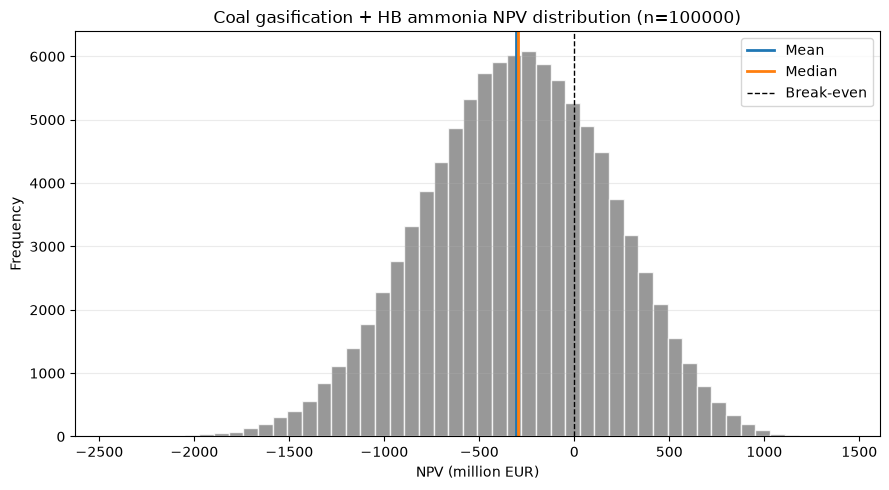

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Coal gasification + HB ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

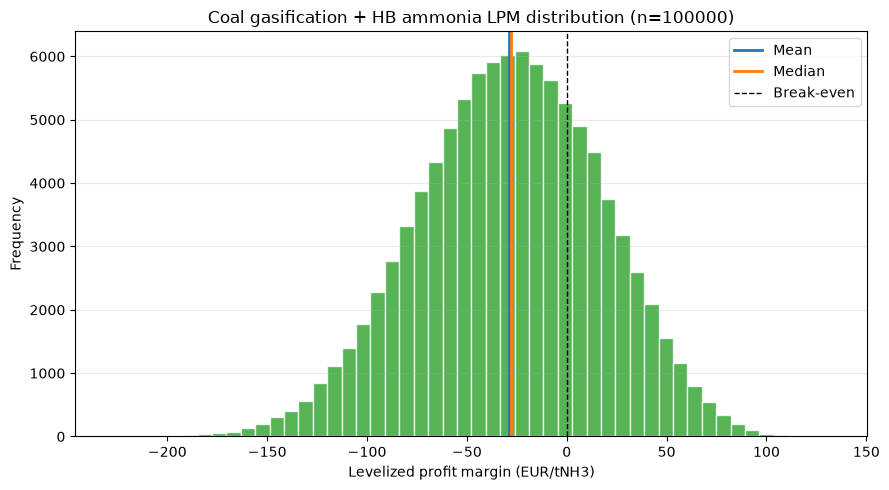

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_tnh3,
    title=f"Coal gasification + HB ammonia LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

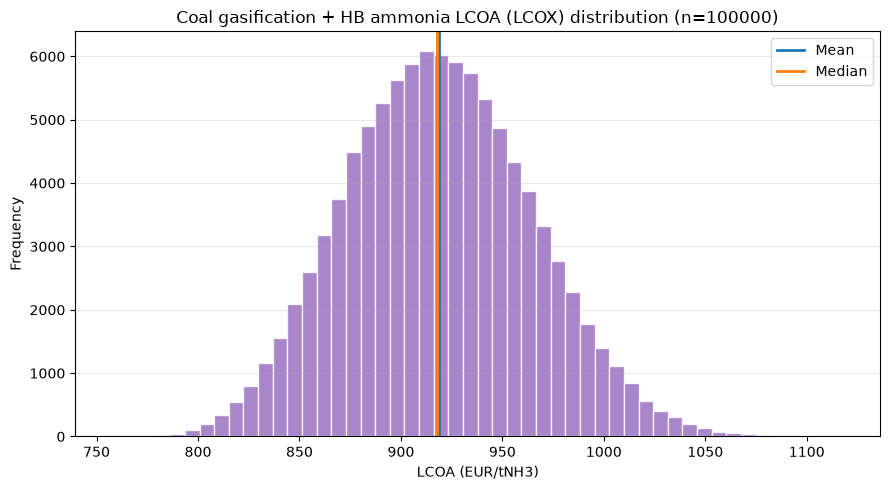

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"Coal gasification + HB ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      890.000
annual_fixed_opex_eur                   116.947
annual_variable_opex_eur                 16.766
annual_natural_gas_cost_eur               0.000
annual_coal_cost_eur                    113.362
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    113.362
annual_electricity_cost_eur             120.103
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur               256.000
annual_net_cash_flow_eur                266.822
Name: Mean annual value, million EUR, dtype: float64